In [13]:
import sys
from pathlib import Path

import torch

# Resolve repo root (cwd may be repo root, notebooks/, or elsewhere)
_here = Path.cwd().resolve()
_root = next(
    (p for p in (_here, *_here.parents) if (p / "src" / "dynarope").is_dir()),
    _here,
)
_src = _root / "src"
if str(_src) in sys.path:
    sys.path.remove(str(_src))
sys.path.insert(0, str(_src))

# Jupyter / re-runs: drop cached dynarope if a stale (e.g. empty) module was loaded earlier
for _name in list(sys.modules):
    if _name == "dynarope" or _name.startswith("dynarope."):
        del sys.modules[_name]

from dynarope.attention import RoPEAttention

if __name__ == "__main__":
    d_model = 256
    n_heads = 8
    seq_len = 1024
    batch_size = 1
    
    # Initialize our custom Attention Layer
    attention_layer = RoPEAttention(d_model=d_model, n_heads=n_heads)
    
    # Create a dummy sentence tensor (Batch, Seq_Len, Embed_Dim)
    dummy_input = torch.randn(batch_size, seq_len, d_model)
    
    # Run the forward pass
    output = attention_layer(dummy_input)
    
    print(f"Input shape:  {dummy_input.shape}")
    print(f"Output shape: {output.shape}")
    print("Forward pass successful. Q and K successfully intercepted and rotated.")

Input shape:  torch.Size([1, 1024, 256])
Output shape: torch.Size([1, 1024, 256])
Forward pass successful. Q and K successfully intercepted and rotated.


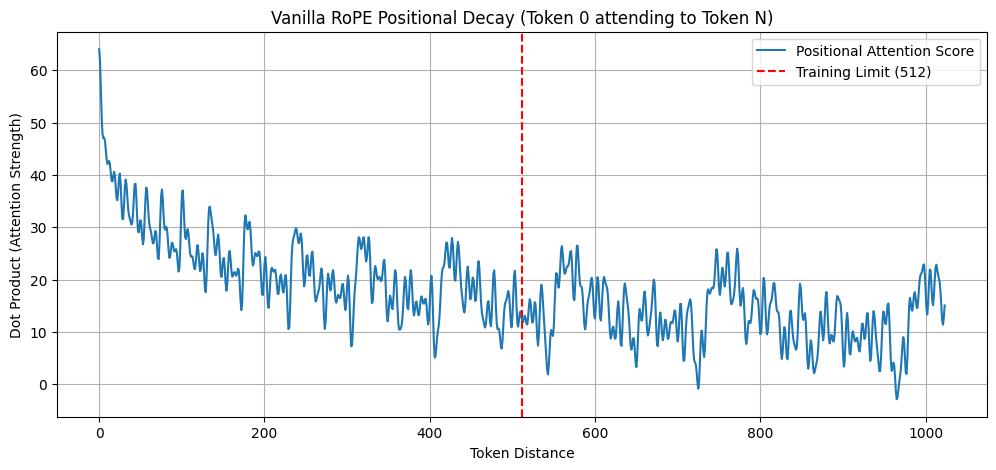

In [15]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

_here = Path.cwd().resolve()
_root = next(
    (p for p in (_here, *_here.parents) if (p / "src" / "dynarope").is_dir()),
    _here,
)
_src = _root / "src"
if str(_src) in sys.path:
    sys.path.remove(str(_src))
sys.path.insert(0, str(_src))

from dynarope.core import apply_rotary_emb, precompute_freqs_cis


def visualize_rope_decay():
    seq_len = 1024
    head_dim = 64
    
    # 1. Create a dummy sequence of IDENTICAL tokens (all 1s)
    # Shape: (1 batch, seq_len, 1 head, head_dim)
    q = torch.ones(1, seq_len, 1, head_dim)
    k = torch.ones(1, seq_len, 1, head_dim)
    
    # 2. Precompute the standard RoPE frequencies
    freqs_cis = precompute_freqs_cis(dim=head_dim, seq_len=seq_len)
    
    # 3. Apply the complex rotations
    q_rot, k_rot = apply_rotary_emb(q, k, freqs_cis)
    
    # 4. Calculate the Attention Dot Product between Token 0 and ALL other tokens
    # We take the first query token and multiply it by all key tokens
    q_zero = q_rot[0, 0, 0, :]  # Shape: (64)
    k_all = k_rot[0, :, 0, :]   # Shape: (1024, 64)
    
    # The dot product represents the "Positional Attention Score"
    attention_scores = torch.matmul(k_all, q_zero).numpy()
    
    # 5. Plot the results
    plt.figure(figsize=(12, 5))
    plt.plot(attention_scores, label="Positional Attention Score")
    plt.axvline(x=512, color='r', linestyle='--', label='Training Limit (512)')
    
    plt.title("Vanilla RoPE Positional Decay (Token 0 attending to Token N)")
    plt.xlabel("Token Distance")
    plt.ylabel("Dot Product (Attention Strength)")
    plt.legend()
    plt.grid(True)
    plt.show()

visualize_rope_decay()